## Setup

In [60]:
import pandas as pd
import os
import json
import ast
import copy
import re
import torch
import numpy as np
import chromadb
import time

from openai import RateLimitError
from tqdm.notebook import tqdm
from chromadb.utils import embedding_functions
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from sentence_transformers import SentenceTransformer
from pathlib import Path
from datasets import load_dataset
from openai import OpenAI
from dotenv import load_dotenv

In [61]:
load_dotenv()

RANDOM_SEED = 42
BUFFER_SIZE = 10_000
SAMPLE_SIZE = 100
MODEL_ID = "nvidia/nemotron-3-super-120b-a12b:free"
EMBEDDING_MODEL_ID = "sentence-transformers/all-mpnet-base-v2"
EMBEDDING_BATCH_SIZE = 256

DATA_PATH = Path("./data")
RAW_1P_DATA_PATH = DATA_PATH / "input" / "aei_raw_1p_api_2026-02-05_to_2026-02-12.csv"
RAW_CLAUDE_DATA_PATH = DATA_PATH / "input" / "aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv"
PROMPTS_DIR = Path("./prompts")
WORK_RELATED_PROMPT_PATH = PROMPTS_DIR / "work_related.json"

CHROMA_DB_PATH = DATA_PATH / "chroma"
CLUSTERS_COLLECTION_NAME = "clusters"

OUTPUT_DIR = DATA_PATH / "output"
WORK_RELATED_OUTPUT_PATH = OUTPUT_DIR / f"work_related_{SAMPLE_SIZE}.csv"
HIERARCHY_OUTPUT_PATH = OUTPUT_DIR / "hierarchy.csv"
TASK_MAPPING_OUTPUT_PATH = OUTPUT_DIR / f"task_mapping_{SAMPLE_SIZE}.csv"

WILDCHAT_DATASET = "allenai/WildChat-4.8M"
WILDCHAT_SAMPLES_FILE = DATA_PATH / "input" / "WildChat-4.8M-sample.csv"
CONVERSATION_FIELD = "conversation"
LANGUAGE_FIELD = "language"
TARGET_LANGUAGE = "English"

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"


PARENT_COLUMN = "parent_id"
COUNT_VARIABLE = "onet_task_count"

In [62]:
device = ""

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [63]:
model = SentenceTransformer(EMBEDDING_MODEL_ID).to(device=device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [64]:
client = OpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=OPENROUTER_API_KEY,
)

In [65]:
chroma = chromadb.PersistentClient(path=CHROMA_DB_PATH)

## Conversation-task mapping
In order to map conversations to tasks, we are using the following steps:

1. Retrieve the conversations from Wildchat, sampling for English conversations 
2. Filter out all the non-work-related conversations
3. Retrieve the task hierarchy from the Anthropic's dataset
4. Map through the hierarchy

In [ ]:
def strip_messages(msgs: list[dict[str, str]]) -> list[dict[str, str]]:
    return [{"role": m["role"], "content": m["content"]} for m in msgs]

In [66]:
if not WILDCHAT_SAMPLES_FILE.exists():
    wildchat_ds = load_dataset(
        WILDCHAT_DATASET,
        split="train",
        streaming=True
    )
    english_conversations_rows = wildchat_ds.filter(lambda x: x[LANGUAGE_FIELD] == TARGET_LANGUAGE)
    sample_conversations_rows = pd.DataFrame(english_conversations_rows.shuffle(
        seed=RANDOM_SEED,
        buffer_size=BUFFER_SIZE
    ).take(SAMPLE_SIZE))
    sample_conversations = sample_conversations_rows[[CONVERSATION_FIELD]].copy()
    sample_conversations[CONVERSATION_FIELD] = sample_conversations[CONVERSATION_FIELD].apply(strip_messages)
    sample_conversations.to_csv(
        path_or_buf=WILDCHAT_SAMPLES_FILE,
        columns=["conversation"],
    )
else:
    sample_conversations = pd.read_csv(WILDCHAT_SAMPLES_FILE)
    sample_conversations["conversation"] = sample_conversations["conversation"].apply(ast.literal_eval)

Resolving data files:   0%|          | 0/86 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/86 [00:00<?, ?it/s]

/var/folders/tc/wc9p1tw950bb9449rjnj5n680000gn/T/ipykernel_20954/2100665773.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_conversations[CONVERSATION_FIELD] = sample_conversations[CONVERSATION_FIELD].apply(_strip_messages)


In [67]:
sample_df = pd.DataFrame(sample_conversations.head())
sample_df.head()

,conversation
0,"[{'role': 'user', 'content': 'i own a rusty 19..."
1,"[{'role': 'user', 'content': 'Make the first p..."
2,"[{'role': 'user', 'content': 'How to be a good..."
3,"[{'role': 'user', 'content': 'freedom planet a..."
4,"[{'role': 'user', 'content': 'what to positive..."


In [68]:
def get_gpt_response(messages: list[dict[str, str]], max_retries: int = 5) -> str:
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_ID,
                messages=messages,
            )
            content = response.choices[0].message.content
            if content is None:
                print(f"Warning: received null content from API (attempt {attempt + 1})")
                return ""
            dirty_result = content.strip()
            cleaned_result = re.search(r'<answer>(.*?)</answer>', dirty_result, re.DOTALL)
            if cleaned_result:
                return cleaned_result.group(1)
            return ""
        except RateLimitError as e:
            wait = 2 ** attempt
            print(f"Rate limited (429). Waiting {wait}s before retry {attempt + 1}/{max_retries}...")
            time.sleep(wait)
    print(f"Failed after {max_retries} retries.")
    return ""


In [69]:
def get_messages(path: Path) -> list[dict[str, str]]:
    with open(path, "r") as f:
        return json.load(f)

In [70]:
def format_conversation(conversation: list[dict[str, str]]) -> str:
    formatted = ""
    for message in conversation:
        role = message["role"]
        content = message["content"]
        formatted += f"{role}: {content}\n"
    return formatted

In [71]:
def build_messages(template: list[dict[str, str]], **kwargs):
    msgs = copy.deepcopy(template)
    for msg in msgs:
        for key, value in kwargs.items():
            if "{" + key + "}" in msg["content"]:
                msg["content"] = msg["content"].replace("{" + key + "}", value)
    return msgs

In [72]:
def filter_work_conversations(conversations: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame()
    template = get_messages(WORK_RELATED_PROMPT_PATH)
    for index, row in conversations.iterrows():
        raw_conversation = row["conversation"]
        conversation = format_conversation(conversation=raw_conversation)
        messages = build_messages(template=template, conversation=conversation)
        response = get_gpt_response(messages=messages)
        record = [{"conversation": conversation, "is_work_related": response}]
        result = pd.concat([result, pd.DataFrame(record)], ignore_index=True)
    return result

In [73]:
if not WORK_RELATED_OUTPUT_PATH.exists():
    work_related_conversations_df = filter_work_conversations(conversations=sample_conversations)
    work_related_conversations_df.to_csv(WORK_RELATED_OUTPUT_PATH)
else:
    work_related_conversations_df = pd.read_csv(WORK_RELATED_OUTPUT_PATH)
    work_related_conversations_df = work_related_conversations_df[work_related_conversations_df["is_work_related"] == "Yes"]
work_related_conversations_df.head()

,Unnamed: 0,conversation,is_work_related
1,1,user: Make the first part of the Delta Systems...,Yes
2,2,user: How to be a good police officer \nassist...,Yes
4,4,user: what to positively answer to following j...,Yes
5,5,user: 翻成英文：猫为什么会在天上飞\nassistant: Why do cats f...,Yes
6,6,user: Rewrite and format the following comment...,Yes


In [74]:
raw_1p_api_df = pd.read_csv(RAW_1P_DATA_PATH)
raw_claude_api_df = pd.read_csv(RAW_CLAUDE_DATA_PATH)

In [75]:
raw_claude_api_df.head()

,geo_id,geography,date_start,date_end,platform_and_product,facet,level,variable,cluster_name,value
0,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,directive,15.000000
1,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,directive,20.270270
2,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,learning,20.000000
3,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_pct,learning,27.027027
4,AD,country,2026-02-05,2026-02-12,"Claude AI (Free, Pro, and Max)",collaboration,0,collaboration_count,not_classified,16.000000


In [76]:
raw_claude_api_df["cluster_name"] = raw_claude_api_df["cluster_name"].str.split("::").str[0]
columns_to_keep = ["level", "cluster_name"]
clusters_df = (
    raw_claude_api_df[columns_to_keep]
   .drop_duplicates()
   .reset_index(drop=True)
   .iloc[50:]
)

clusters_df.reset_index(inplace=True, drop=True)
clusters_df.head()

,level,cluster_name
0,0,"present investment information, such as produc..."
1,0,"provide advice to clients on a contract basis,..."
2,0,"provide clients with communication assistance,..."
3,0,provide feedback and recommendations to develo...
4,0,provide information and advice to the public r...


In [77]:
collection = chroma.get_or_create_collection(
    name=CLUSTERS_COLLECTION_NAME,
    embedding_function=embedding_functions.SentenceTransformerEmbeddingFunction(model_name=EMBEDDING_MODEL_ID),
    metadata={"hnsw:space": "cosine"},
)

if collection.count() == 0:
    embeddings = model.encode(
        clusters_df["cluster_name"].to_list(),
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
    )

    collection.add(
        ids=clusters_df.index.astype(str).tolist(),
        embeddings=embeddings,
        metadatas=clusters_df[["level", "cluster_name"]].to_dict(orient="records"),
    )
else:
    response = collection.get(
        ids=clusters_df.index.astype(str).tolist(),
        include=["embeddings"],
    )
    embeddings_map = {
        int(id): emb
        for id, emb in zip(response["ids"], response["embeddings"])
    }
    embeddings = [embeddings_map[idx] for idx in clusters_df.index]

clusters_df["embedding"] = list(embeddings)
clusters_df["id"] = clusters_df.index

In [78]:
level_0 = clusters_df[clusters_df["level"] == 0].copy()
level_1 = clusters_df[clusters_df["level"] == 1].copy()
level_2 = clusters_df[clusters_df["level"] == 2].copy()

level_2[PARENT_COLUMN] = None

In [79]:
level_2.head()

,level,cluster_name,embedding,id,parent_id
160,2,"Assist with SQL databases, data analysis, and ...","[-0.03694913908839226, 0.019519593566656113, -...",160,None
161,2,"Assist with academic research, scientific writ...","[0.051645293831825256, -0.033810149878263474, ...",161,None
162,2,"Assist with business development, analysis, re...","[0.03184925764799118, 0.007185220718383789, -0...",162,None
163,2,"Assist with civic information, government serv...","[-0.007476258557289839, 0.09170791506767273, -...",163,None
164,2,"Assist with creative content, marketing, and m...","[0.04620485380291939, 0.011296493001282215, -0...",164,None


In [80]:
def assign_parents(parents: pd.DataFrame, children: pd.DataFrame):
    children_matrix = np.stack(children["embedding"])
    parent_matrix = np.stack(parents["embedding"])
    similarity_matrix = cosine_similarity(children_matrix, parent_matrix)
    most_similar_parent_indices = similarity_matrix.argmax(axis=1)
    children[PARENT_COLUMN] = parents["id"].iloc[most_similar_parent_indices].values
    return children

In [81]:
level_0 = assign_parents(parents=level_1, children=level_0)
level_1 = assign_parents(parents=level_2, children=level_1)
hierarchy_df = pd.concat([level_0, level_1, level_2], ignore_index=True)
hierarchy_df.drop(columns=["embedding"], inplace=True)
hierarchy_df.to_csv(HIERARCHY_OUTPUT_PATH, index=False)
hierarchy_df.head()

,level,cluster_name,id,parent_id
0,0,"present investment information, such as produc...",0,147
1,0,"provide advice to clients on a contract basis,...",1,152
2,0,"provide clients with communication assistance,...",2,124
3,0,provide feedback and recommendations to develo...,3,94
4,0,provide information and advice to the public r...,4,147


In [82]:
def get_task_id(task_name: str, hierarchy: pd.DataFrame) -> int:
    record = hierarchy[hierarchy["cluster_name"] == task_name]
    if not record.empty:
        return record["id"].values[0]
    return None

In [83]:
def format_options(tasks: pd.DataFrame) -> str:
    options_str = ""
    for _, row in tasks.iterrows():
        option_name = row["cluster_name"]
        options_str += f"{option_name}\n"
    return options_str

In [84]:
def map_conversation_to_task(conversations: pd.DataFrame, tasks: pd.DataFrame) -> pd.DataFrame:
    template = get_messages(PROMPTS_DIR / "task_mapping.json")
    result = pd.DataFrame(columns=["conversation", "level_2_task", "level_1_task", "level_0_task"])

    for index, row in conversations.iterrows():
        raw_conversation = row["conversation"]
        conversation = format_conversation(conversation=raw_conversation)
        record = {"conversation": conversation, "level_2_task": None, "level_1_task": None, "level_0_task": None}

        high_level_tasks = tasks[tasks["level"] == 2]
        options_str = format_options(tasks=high_level_tasks)
        messages = build_messages(template=template, conversation=conversation, options_str=options_str)
        level_2_response = get_gpt_response(messages=messages).strip()
        record["level_2_task"] = level_2_response

        parent_id = get_task_id(task_name=level_2_response, hierarchy=tasks)
        medium_level_tasks = tasks[(tasks["level"] == 1) & (tasks["parent_id"] == parent_id)]
        options_str = format_options(tasks=medium_level_tasks)
        messages = build_messages(template=template, conversation=conversation, options_str=options_str)
        level_1_response = get_gpt_response(messages=messages).strip()
        record["level_1_task"] = level_1_response

        parent_id = get_task_id(task_name=level_1_response, hierarchy=tasks)
        low_level_tasks = tasks[(tasks["level"] == 0) & (tasks["parent_id"] == parent_id)]
        options_str = format_options(tasks=low_level_tasks)
        messages = build_messages(template=template, conversation=conversation, options_str=options_str)
        level_0_response = get_gpt_response(messages=messages).strip()
        record["level_0_task"] = level_0_response

        result = pd.concat([result, pd.DataFrame([record])], ignore_index=True)

    return result

In [85]:
if not TASK_MAPPING_OUTPUT_PATH.exists():
    mapped_conversations_df = map_conversation_to_task(
        conversations=sample_conversations,
        tasks=hierarchy_df
    )
    mapped_conversations_df.to_csv(TASK_MAPPING_OUTPUT_PATH, index=False)
else:
    mapped_conversations_df = pd.read_csv(TASK_MAPPING_OUTPUT_PATH)
mapped_conversations_df.head()

,conversation,level_2_task,level_1_task,level_0_task
0,user: i own a rusty 1975 plymouth fury beater....,"Get help with daily life tasks, personal infor...","Get help with home maintenance, repairs, vehic...",Provide information and assistance on automoti...
1,user: Make the first part of the Delta Systems...,"Assist with creative content, marketing, and m...","Assist with creative fiction writing, editing,...",Get creative writing assistance for fiction de...
2,user: How to be a good police officer \nassist...,"Assist with civic information, government serv...",Career counseling,Providing advice
3,user: freedom planet all characters react to g...,"Assist with creative content, marketing, and m...","Assist with creative fiction writing, editing,...",Write and develop fanfiction stories based on ...
4,user: what to positively answer to following j...,"Assist with job applications, career transitio...","Create and optimize resumes, cover letters, an...",Draft and refine cover letters for job applica...


## Role extraction
In order to extract the roles, we are using the following steps:

1. Prompt the LLM.
2. Extract embeddings from all the descriptions
3. Cluster the embeddings using hierarchical agglomerative clustering
4. Assign a role to each cluster based on the content of the cluster
5. Validate the roles obtained by comparing them against the TUNA taxonomy

I'm putting an example of how the clustering would look like with random embeddings, since we don't have the actual embeddings yet.

In [86]:
embedding_descriptions = np.random.rand(100, 1024)

In [87]:
linked = linkage(y=embedding_descriptions, method="ward")
labelList = range(1, 101)

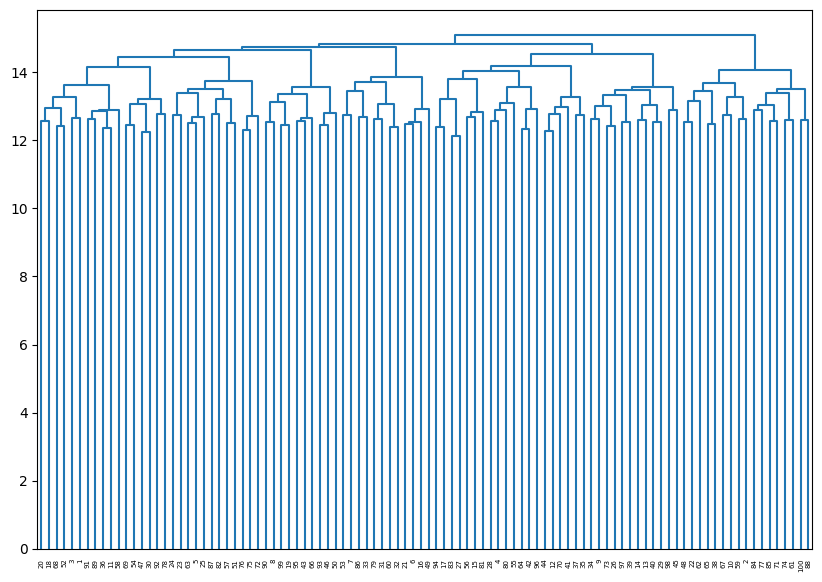

In [88]:
plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            labels=labelList,
            distance_sort='descending',
            show_leaf_counts=True)
plt.show()